In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("brfss_clean_2020_2024.csv")

race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

# Drop 2020 — no income
df_model = df.dropna(subset=["race_group", "age_group", "sex",
                               "education", "income_group", "obese"]).copy()

print("Model dataset:", len(df_model))
print("Obesity prevalence:", df_model["obese"].mean().round(4))

Model dataset: 1322240
Obesity prevalence: 0.3451


In [2]:
# Encode state
le_state = LabelEncoder()
df_model["state_code"] = le_state.fit_transform(df_model["_STATE"])

# One-hot encode demographics
feature_cols_base = ["age_group", "sex", "education", "income_group", "race_group"]
df_encoded = pd.get_dummies(df_model[feature_cols_base], drop_first=True)

# Add state dummies
state_dummies = pd.get_dummies(df_model["state_code"], prefix="state", drop_first=True)
X = pd.concat([df_encoded, state_dummies], axis=1)
y = df_model["obese"].values
w = df_model["_LLCPWT_adjusted"].values

# Train test split — stratified
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Features:", X.shape[1])
print("Train obesity rate:", y_train.mean().round(4))
print("Test obesity rate:", y_test.mean().round(4))

Train size: 1057792
Test size: 264448
Features: 81
Train obesity rate: 0.3451
Test obesity rate: 0.3451


In [3]:
from time import time

results = {}

# Model 1 — Logistic Regression
print("Fitting Logistic Regression...")
t0 = time()
lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X_train, y_train, sample_weight=w_train)
t1 = time()

lr_pred = lr.predict_proba(X_test)[:, 1]
results["Logistic Regression"] = {
    "auc": roc_auc_score(y_test, lr_pred, sample_weight=w_test),
    "brier": brier_score_loss(y_test, lr_pred, sample_weight=w_test),
    "pred_std": lr_pred.std(),
    "pred_mean": lr_pred.mean(),
    "time_sec": round(t1 - t0, 1)
}
print(f"  Done in {t1-t0:.1f}s — AUC: {results['Logistic Regression']['auc']:.4f}")

# Model 2 — Random Forest
print("\nFitting Random Forest...")
t0 = time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train, sample_weight=w_train)
t1 = time()

rf_pred = rf.predict_proba(X_test)[:, 1]
results["Random Forest"] = {
    "auc": roc_auc_score(y_test, rf_pred, sample_weight=w_test),
    "brier": brier_score_loss(y_test, rf_pred, sample_weight=w_test),
    "pred_std": rf_pred.std(),
    "pred_mean": rf_pred.mean(),
    "time_sec": round(t1 - t0, 1)
}
print(f"  Done in {t1-t0:.1f}s — AUC: {results['Random Forest']['auc']:.4f}")

# Model 3 — Gradient Boosting
print("\nFitting Gradient Boosting...")
t0 = time()
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train, sample_weight=w_train)
t1 = time()

gb_pred = gb.predict_proba(X_test)[:, 1]
results["Gradient Boosting"] = {
    "auc": roc_auc_score(y_test, gb_pred, sample_weight=w_test),
    "brier": brier_score_loss(y_test, gb_pred, sample_weight=w_test),
    "pred_std": gb_pred.std(),
    "pred_mean": gb_pred.mean(),
    "time_sec": round(t1 - t0, 1)
}
print(f"  Done in {t1-t0:.1f}s — AUC: {results['Gradient Boosting']['auc']:.4f}")

# Summary table
print("\n=== MODEL COMPARISON ===")
results_df = pd.DataFrame(results).T
results_df.columns = ["Weighted AUC", "Weighted Brier", "Pred Std Dev", "Pred Mean", "Time (sec)"]
results_df = results_df.round(4)
print(results_df.to_string())

Fitting Logistic Regression...
  Done in 1.6s — AUC: 0.6354

Fitting Random Forest...
  Done in 7.6s — AUC: 0.6243

Fitting Gradient Boosting...
  Done in 76.7s — AUC: 0.6378

=== MODEL COMPARISON ===
                     Weighted AUC  Weighted Brier  Pred Std Dev  Pred Mean  Time (sec)
Logistic Regression        0.6354          0.2135        0.0968     0.3410         1.6
Random Forest              0.6243          0.2171        0.0478     0.3372         7.6
Gradient Boosting          0.6378          0.2134        0.0830     0.3366        76.7


In [4]:
# Load group summary
df_summary = pd.read_csv("brfss_group_summary_modeled.csv")
group_cols = ["age_group", "sex", "education", "income_group", "race_group"]

# Encode cells
cells = df_summary[group_cols].copy()
cells_encoded = pd.get_dummies(cells[group_cols], drop_first=True)

for col in df_encoded.columns:
    if col not in cells_encoded.columns:
        cells_encoded[col] = 0
cells_encoded = cells_encoded[df_encoded.columns]

for col in state_dummies.columns:
    cells_encoded[col] = 0

# Predict from all three models
cells["lr_modeled"]   = lr.predict_proba(cells_encoded)[:, 1]
cells["rf_modeled"]   = rf.predict_proba(cells_encoded)[:, 1]
cells["gb_modeled"]   = gb.predict_proba(cells_encoded)[:, 1]

print("Cell-level prediction comparison:")
print(f"\nLogistic Regression:")
print(f"  Mean: {cells['lr_modeled'].mean():.4f}  Std: {cells['lr_modeled'].std():.4f}")
print(f"  Min:  {cells['lr_modeled'].min():.4f}  Max: {cells['lr_modeled'].max():.4f}")

print(f"\nRandom Forest:")
print(f"  Mean: {cells['rf_modeled'].mean():.4f}  Std: {cells['rf_modeled'].std():.4f}")
print(f"  Min:  {cells['rf_modeled'].min():.4f}  Max: {cells['rf_modeled'].max():.4f}")

print(f"\nGradient Boosting:")
print(f"  Mean: {cells['gb_modeled'].mean():.4f}  Std: {cells['gb_modeled'].std():.4f}")
print(f"  Min:  {cells['gb_modeled'].min():.4f}  Max: {cells['gb_modeled'].max():.4f}")

print(f"\nCorrelation between model predictions:")
print(cells[["lr_modeled", "rf_modeled", "gb_modeled"]].corr().round(4))

Cell-level prediction comparison:

Logistic Regression:
  Mean: 0.3495  Std: 0.1167
  Min:  0.0427  Max: 0.5765

Random Forest:
  Mean: 0.3356  Std: 0.0626
  Min:  0.1277  Max: 0.4628

Gradient Boosting:
  Mean: 0.3324  Std: 0.1016
  Min:  0.0796  Max: 0.5820

Correlation between model predictions:
            lr_modeled  rf_modeled  gb_modeled
lr_modeled      1.0000      0.8804      0.9204
rf_modeled      0.8804      1.0000      0.9486
gb_modeled      0.9204      0.9486      1.0000


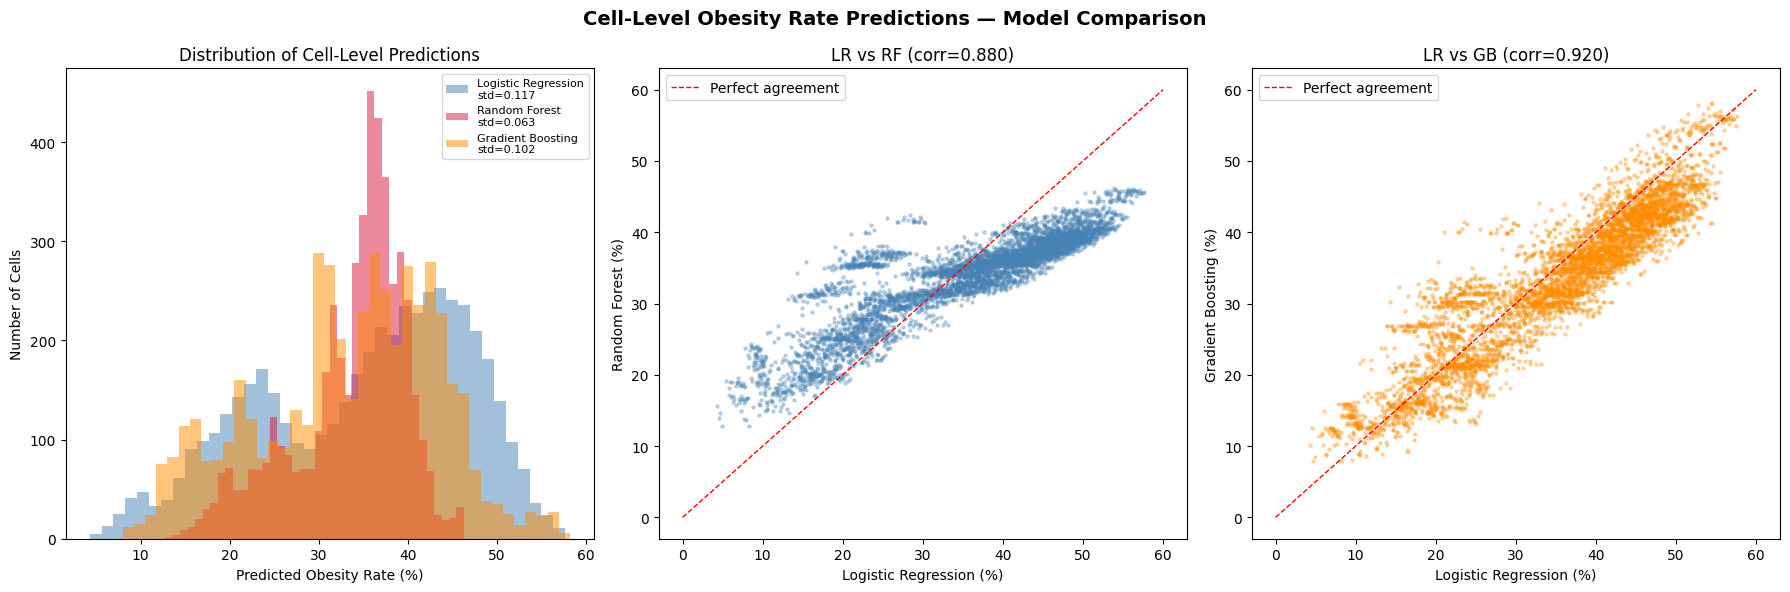

saved brfss_model_comparison_plots.png
saved brfss_model_comparison.csv


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Cell-Level Obesity Rate Predictions — Model Comparison", 
             fontsize=14, fontweight="bold")

models = {
    "Logistic Regression": ("lr_modeled", "steelblue"),
    "Random Forest": ("rf_modeled", "crimson"),
    "Gradient Boosting": ("gb_modeled", "darkorange")
}

# Plot 1 — Distribution of cell predictions
ax = axes[0]
for name, (col, color) in models.items():
    ax.hist(cells[col] * 100, bins=40, alpha=0.5, 
            color=color, label=f"{name}\nstd={cells[col].std():.3f}")
ax.set_xlabel("Predicted Obesity Rate (%)")
ax.set_ylabel("Number of Cells")
ax.set_title("Distribution of Cell-Level Predictions")
ax.legend(fontsize=8)

# Plot 2 — Scatter LR vs RF
ax = axes[1]
ax.scatter(cells["lr_modeled"] * 100, cells["rf_modeled"] * 100,
           alpha=0.3, s=5, color="steelblue")
ax.plot([0, 60], [0, 60], "r--", linewidth=1, label="Perfect agreement")
ax.set_xlabel("Logistic Regression (%)")
ax.set_ylabel("Random Forest (%)")
ax.set_title(f"LR vs RF (corr={cells['lr_modeled'].corr(cells['rf_modeled']):.3f})")
ax.legend()

# Plot 3 — Scatter LR vs GB
ax = axes[2]
ax.scatter(cells["lr_modeled"] * 100, cells["gb_modeled"] * 100,
           alpha=0.3, s=5, color="darkorange")
ax.plot([0, 60], [0, 60], "r--", linewidth=1, label="Perfect agreement")
ax.set_xlabel("Logistic Regression (%)")
ax.set_ylabel("Gradient Boosting (%)")
ax.set_title(f"LR vs GB (corr={cells['lr_modeled'].corr(cells['gb_modeled']):.3f})")
ax.legend()

plt.tight_layout()
plt.savefig("brfss_model_comparison_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_model_comparison_plots.png")

# Save comparison results
results_df.to_csv("brfss_model_comparison.csv")
print("saved brfss_model_comparison.csv")